# How do structural descriptors see a melting crystal?

This notebook compares three primary discrete structure classifiers (adaptive CNA, interval CNA, and PTM), keeps fixed-cutoff CNA as a scale-sensitive diagnostic, and evaluates three Steinhardt neighborhood conventions for FCC and HCP trajectories.

The sampling has two complementary resolutions: a coarse full-run overview and **every stored trajectory frame** in a focused window around the steepest global $Q_6$ decline. Late frames are also retained for the empirical-liquid reference. Scatter plots still draw only a subset of atoms where overplotting would hide the distributions.

It shows structure populations, per-atom classifier agreement, standard, Lechner–Dellago averaged, and Voronoi-facet-weighted $q_4/q_6$ and normalized $\hat w_4/\hat w_6$ spaces, and a frame-resolved estimate of how quickly the descriptor jump occurs.

> **Trajectory note.** The revised HCP trajectory contains a late melting transition under the same gentle pressure-driven protocol and output cadence as FCC. Both runs equilibrate through step 200,000 and then begin the pressure ramp. The notebook infers trajectory cadence automatically.

Run this with the `autoencode-statmech` conda environment; it contains OVITO, freud, pandas, scikit-learn, and matplotlib.

In [1]:
from collections import OrderedDict
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message=".*OVITO.*PyPI")

import freud
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
import numpy as np
import pandas as pd
from IPython.display import display
from ovito.io import import_file
from ovito.modifiers import CommonNeighborAnalysisModifier, PolyhedralTemplateMatchingModifier
from ovito.pipeline import Pipeline, StaticSource

plt.style.use("seaborn-v0_8-whitegrid")

def find_data_root():
    candidates = [Path.cwd(), Path.cwd() / "melting-crystals", Path.cwd().parent / "melting-crystals"]
    for candidate in candidates:
        if (candidate / "fcc/melting.lammpstrj").exists():
            return candidate.resolve()
    raise FileNotFoundError("Start the notebook in or directly above the melting-crystals directory.")

ROOT = find_data_root()
OVERVIEW_MAX_FRAMES = 31
EVENT_WINDOW_BEFORE = 50_000
EVENT_WINDOW_AFTER = 50_000
LATE_REFERENCE_FRAMES = 16
RANDOM_REFERENCE_PARTICLES = 5000
LIQUID_CONSENSUS_THRESHOLD = 0.99
COMPLETE_COLLAPSE_THRESHOLD = LIQUID_CONSENSUS_THRESHOLD
LIQUID_MSD_THRESHOLD = 1.0  # sigma^2
RNG = np.random.default_rng(17)

def estimate_random_q6(n_particles=RANDOM_REFERENCE_PARTICLES, seed=2718):
    rng = np.random.default_rng(seed)
    length = float(n_particles ** (1 / 3))
    box = freud.box.Box.cube(length)
    positions = rng.uniform(-length / 2, length / 2, size=(n_particles, 3)).astype(np.float32)
    q6 = freud.order.Steinhardt(l=6).compute((box, positions), neighbors={"num_neighbors": 12})
    return float(np.nanmean(q6.particle_order))

RANDOM_Q6_REFERENCE = estimate_random_q6()
RUNS = OrderedDict({
    "fcc": {"trajectory": ROOT / "fcc/melting.lammpstrj", "observables": ROOT / "fcc/melting_observables.dat",
            "observable_names": ["timestep", "temperature", "pressure", "potential", "volume", "density", "Q6"],
            "expected_id": 1, "ramp_start_step": 200_000, "first_step": 0, "dump_every": 1000},
    "hcp": {"trajectory": ROOT / "hcp/trajectory.lammpstrj", "observables": ROOT / "hcp/melting_observables.dat",
            "observable_names": ["timestep", "temperature", "pressure", "potential", "volume", "density", "Q6"],
            "expected_id": 2, "ramp_start_step": 200_000, "first_step": 0, "dump_every": 1000},
})
print(f"Data root: {ROOT}")
print(f"Sampling: {OVERVIEW_MAX_FRAMES} coarse overview frames + every frame in "
      f"[-{EVENT_WINDOW_BEFORE:,}, +{EVENT_WINDOW_AFTER:,}] steps around the Q6 decline")
print(f"Strict liquid border: >= {LIQUID_CONSENSUS_THRESHOLD:.0%} unanimous Other and "
      f"MSD >= {LIQUID_MSD_THRESHOLD:.1f} sigma^2")

Data root: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/melting-crystals
Sampling: 31 coarse overview frames + every frame in [-50,000, +50,000] steps around the Q6 decline
Strict liquid border: >= 99% unanimous Other and MSD >= 1.0 sigma^2


## 1. Full-run context and frame-resolved melting window

The left column shows the complete simulation with coarse trajectory samples, the start of the pressure-driven melting ramp, and the automatically detected transition window. The right column enlarges the transition and analyzes **every stored trajectory frame**, so a one-frame-looking jump can be distinguished from a short sequence of intermediate states.

The transition centre is the steepest decrease of a 21-point rolling median of global $Q_6$. If $Q_6$ has too little dynamic range to resolve a transition, only full-run coverage is used. The dotted horizontal line is the ideal-gas reference with the same 12-nearest-neighbor definition; it is a limiting reference, not a liquid threshold.

,run,trajectory_frames,analyzed_frames,overview_frames,every_frame_event,late_reference_frames,dump_every,transition_step,event_start,event_end,robust_Q6_range
0,fcc,1201,144,31,101,16,1000,989000,939000,1039000,0.173
1,hcp,1201,145,31,101,16,1000,983000,933000,1033000,0.107


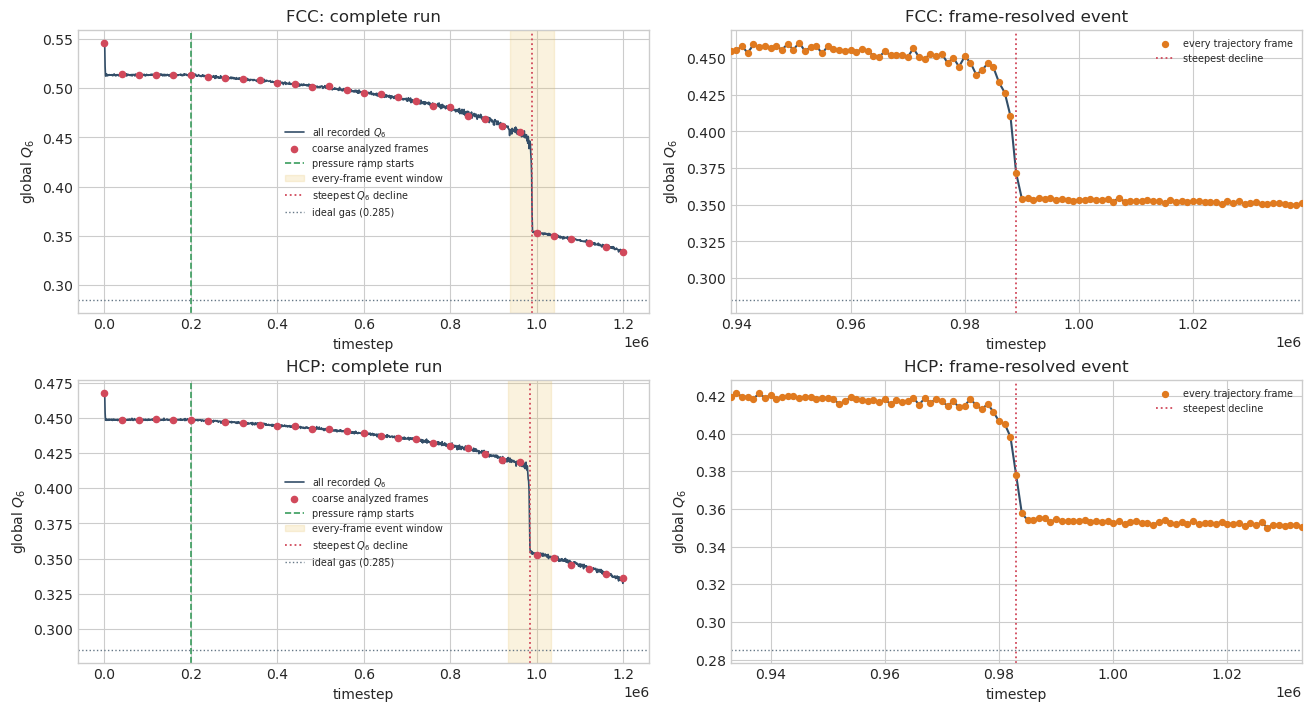

In [2]:
def read_observables(config):
    return pd.read_csv(config["observables"], comment="#", sep=r"\s+",
                       names=config["observable_names"], engine="python")

def choose_frame_indices(observables, config, n_frames):
    q6 = observables["Q6"].astype(float)
    robust_range = q6.quantile(0.95) - q6.quantile(0.05)
    overview = np.unique(np.rint(np.linspace(0, n_frames - 1,
                                             min(OVERVIEW_MAX_FRAMES, n_frames))).astype(int))
    transition_step = None
    event = np.array([], dtype=int)
    if robust_range >= 0.08:
        smooth = q6.rolling(21, center=True, min_periods=3).median()
        transition_step = int(observables.loc[smooth.diff().idxmin(), "timestep"])
        first = max(0, int(np.ceil((transition_step - EVENT_WINDOW_BEFORE - config["first_step"])
                                   / config["dump_every"])))
        last = min(n_frames - 1, int(np.floor((transition_step + EVENT_WINDOW_AFTER - config["first_step"])
                                              / config["dump_every"])))
        event = np.arange(first, last + 1, dtype=int)
        strategy = "coarse full run + every frame around resolved Q6 decline"
    else:
        strategy = "coarse full run (no resolved Q6 transition)"

    tail_start = int(event[-1] + 1) if len(event) else max(0, round(2 * (n_frames - 1) / 3))
    tail = (np.unique(np.rint(np.linspace(tail_start, n_frames - 1,
                                          min(LATE_REFERENCE_FRAMES, n_frames - tail_start))).astype(int))
            if tail_start < n_frames else np.array([], dtype=int))
    selected = np.unique(np.concatenate([overview, event, tail]))
    return selected, overview, event, tail, strategy, robust_range, transition_step

selection_rows = []
sampling_rows = []
for run, config in RUNS.items():
    config["pipeline"] = import_file(str(config["trajectory"]), multiple_frames=True)
    config["first_step"] = int(config["pipeline"].compute(0).attributes["Timestep"])
    if config["pipeline"].num_frames > 1:
        second_step = int(config["pipeline"].compute(1).attributes["Timestep"])
        config["dump_every"] = second_step - config["first_step"]
    config["observables_df"] = read_observables(config)
    selected, overview, event, tail, strategy, q6_range, transition_step = choose_frame_indices(
        config["observables_df"], config, config["pipeline"].num_frames
    )
    config["frame_indices"] = selected
    config["overview_frame_indices"] = overview
    config["event_frame_indices"] = event
    config["late_frame_indices"] = tail
    config["sampling_strategy"] = strategy
    config["transition_step"] = transition_step
    config["event_start_step"] = (config["first_step"] + int(event[0]) * config["dump_every"]
                                  if len(event) else None)
    config["event_end_step"] = (config["first_step"] + int(event[-1]) * config["dump_every"]
                                if len(event) else None)

    overview_set, event_set, tail_set = set(overview), set(event), set(tail)
    for index in selected:
        roles = []
        if int(index) in overview_set: roles.append("coarse overview")
        if int(index) in event_set: roles.append("every-frame event")
        if int(index) in tail_set: roles.append("late reference coverage")
        selection_rows.append({"run": run, "frame_index": int(index),
            "estimated_timestep": config["first_step"] + int(index) * config["dump_every"],
            "sampling_role": " + ".join(roles)})
    sampling_rows.append({"run": run, "trajectory_frames": config["pipeline"].num_frames,
                          "analyzed_frames": len(selected), "overview_frames": len(overview),
                          "every_frame_event": len(event), "late_reference_frames": len(tail),
                          "dump_every": config["dump_every"], "transition_step": transition_step,
                          "event_start": config["event_start_step"], "event_end": config["event_end_step"],
                          "robust_Q6_range": q6_range})
selection = pd.DataFrame(selection_rows)
sampling_summary = pd.DataFrame(sampling_rows)
display(sampling_summary.round(3))

fig, axes = plt.subplots(len(RUNS), 2, figsize=(13, 3.5 * len(RUNS)), constrained_layout=True)
axes = np.atleast_2d(axes)
for row, (run, config) in enumerate(RUNS.items()):
    obs = config["observables_df"]
    overview_steps = config["first_step"] + config["overview_frame_indices"] * config["dump_every"]
    event_steps = config["first_step"] + config["event_frame_indices"] * config["dump_every"]
    overview_ax, event_ax = axes[row]

    overview_ax.plot(obs.timestep, obs.Q6, lw=1.2, color="#334e68", label="all recorded $Q_6$")
    overview_ax.scatter(overview_steps, np.interp(overview_steps, obs.timestep, obs.Q6),
                        color="#d1495b", s=20, zorder=3, label="coarse analyzed frames")
    overview_ax.axvline(config["ramp_start_step"], color="#3a9d5d", ls="--", lw=1.2,
                        label="pressure ramp starts")
    if len(event_steps):
        overview_ax.axvspan(event_steps.min(), event_steps.max(), color="#e9c46a", alpha=.22,
                            label="every-frame event window")
        overview_ax.axvline(config["transition_step"], color="#d1495b", ls=":", lw=1.3,
                            label="steepest $Q_6$ decline")
    overview_ax.axhline(RANDOM_Q6_REFERENCE, color="#657786", ls=":", lw=1,
                        label=f"ideal gas ({RANDOM_Q6_REFERENCE:.3f})")
    overview_ax.set(title=f"{run.upper()}: complete run", xlabel="timestep", ylabel="global $Q_6$")

    if len(event_steps):
        event_obs = obs[obs.timestep.between(event_steps.min(), event_steps.max())]
        event_ax.plot(event_obs.timestep, event_obs.Q6, color="#334e68", lw=1.5)
        event_ax.scatter(event_steps, np.interp(event_steps, obs.timestep, obs.Q6),
                         color="#e07a1f", s=18, zorder=3, label="every trajectory frame")
        event_ax.axvline(config["transition_step"], color="#d1495b", ls=":", lw=1.3,
                         label="steepest decline")
        event_ax.axhline(RANDOM_Q6_REFERENCE, color="#657786", ls=":", lw=1)
        event_ax.set_xlim(event_steps.min(), event_steps.max())
    event_ax.set(title=f"{run.upper()}: frame-resolved event", xlabel="timestep", ylabel="global $Q_6$")
    for ax in (overview_ax, event_ax):
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
        ax.legend(frameon=False, fontsize=7)
plt.show()

## 2. Dynamical sanity check: did each crystal melt?

Structural classifiers alone cannot prove melting, so we check whether atoms lose memory of their original lattice sites and develop growing unwrapped displacement. Unlike the structural analysis, this inexpensive diagnostic now reads **every trajectory frame from the true first frame**. That makes periodic unwrapping reliable and avoids defining the displacement origin at a late sampled state.

The periodic site MSD measures loss of the initial lattice positions; the incrementally unwrapped MSD measures continued motion across the periodic box. It remains a melting diagnostic rather than a precision diffusion-coefficient fit.

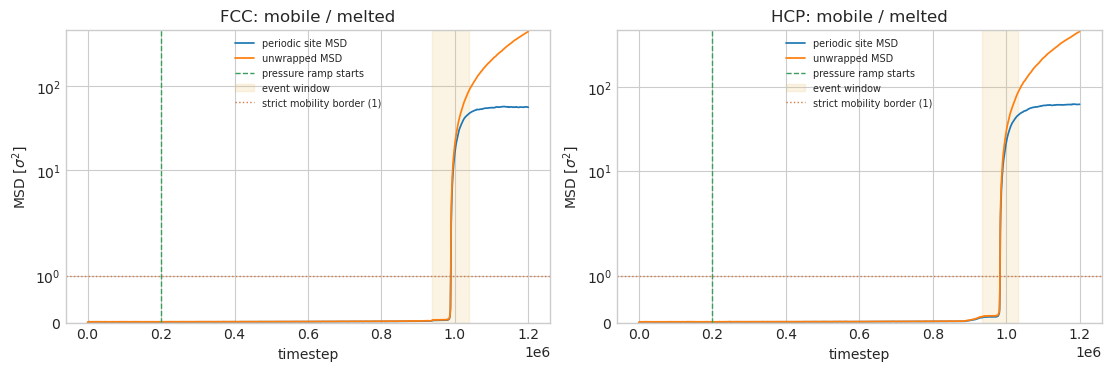

In [3]:
def displacement_diagnostics(config):
    reference = config["pipeline"].compute(0)
    reference_lengths = np.diag(np.asarray(reference.cell)[:, :3])
    reference_fractional = np.asarray(reference.particles.positions) / reference_lengths
    previous_fractional = reference_fractional.copy()
    unwrapped_displacement = np.zeros_like(np.asarray(reference.particles.positions), dtype=float)
    rows = []
    for frame_index in range(config["pipeline"].num_frames):
        frame = config["pipeline"].compute(frame_index)
        current_lengths = np.diag(np.asarray(frame.cell)[:, :3])
        fractional = np.asarray(frame.particles.positions) / current_lengths
        site_delta = fractional - reference_fractional
        site_delta -= np.rint(site_delta)
        site_displacement = site_delta * reference_lengths
        site_displacement -= site_displacement.mean(axis=0)
        step_delta = fractional - previous_fractional
        step_delta -= np.rint(step_delta)
        step_displacement = step_delta * current_lengths
        step_displacement -= step_displacement.mean(axis=0)
        unwrapped_displacement += step_displacement
        previous_fractional = fractional
        rows.append({"frame_index": frame_index, "timestep": int(frame.attributes["Timestep"]),
                     "site_MSD": np.mean(np.sum(site_displacement**2, axis=1)),
                     "unwrapped_MSD": np.mean(np.sum(unwrapped_displacement**2, axis=1))})
    return pd.DataFrame(rows)

dynamics = pd.concat([
    displacement_diagnostics(config).assign(run=run) for run, config in RUNS.items()
], ignore_index=True)

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.6), constrained_layout=True)
for ax, run in zip(np.atleast_1d(axes), RUNS):
    config = RUNS[run]
    part = dynamics[dynamics.run.eq(run)]
    ax.plot(part.timestep, part.site_MSD, label="periodic site MSD", lw=1.25)
    ax.plot(part.timestep, part.unwrapped_MSD, label="unwrapped MSD", lw=1.25)
    ax.axvline(config["ramp_start_step"], color="#3a9d5d", ls="--", lw=1,
               label="pressure ramp starts")
    if config["event_start_step"] is not None:
        ax.axvspan(config["event_start_step"], config["event_end_step"], color="#e9c46a", alpha=.18,
                   label="event window")
    ax.axhline(LIQUID_MSD_THRESHOLD, color="#d17a45", ls=":", lw=1,
               label=f"strict mobility border ({LIQUID_MSD_THRESHOLD:g})")
    melted = part.unwrapped_MSD.tail(10).median() > LIQUID_MSD_THRESHOLD
    ax.set(title=f"{run.upper()}: {'mobile / melted' if melted else 'caged'}", xlabel="timestep",
           ylabel=r"MSD [$\sigma^2$]", yscale="symlog", ylim=(-1e-3, None))
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    ax.legend(frameon=False, fontsize=7)
plt.show()

## 3. Register and run the methods

Fixed CNA uses the FCC-oriented reduced-LJ cutoff 1.5; PTM uses RMSD cutoff 0.10. Cutoff 1.5 is too broad for the thermally smeared HCP neighbor shells, which is why fixed CNA calls that run almost entirely `other`; adaptive/interval CNA and PTM are the meaningful HCP comparisons. `Other` is not a perfect liquid label: it also includes defects and distorted crystal environments. Standard and Lechner–Dellago descriptors use 12 nearest neighbors; facet-weighted descriptors use Voronoi facet-area weights. The $w_l$ values are normalized third-order invariants.

In [4]:
STRUCTURE_NAMES = {0: "other / liquid-like", 1: "FCC", 2: "HCP", 3: "BCC", 4: "ICO",
                   5: "SC", 6: "cubic diamond", 7: "hexagonal diamond", 8: "graphene"}
STRUCTURE_COLORS = {"other / liquid-like": "#9aa5b1", "FCC": "#2878b5", "HCP": "#e07a1f",
                    "BCC": "#3a9d5d", "ICO": "#a05eb5", "SC": "#8c6d31",
                    "cubic diamond": "#d65f5f", "hexagonal diamond": "#6f63b6", "graphene": "#4f9d9d"}
CLASSIFIER_FACTORIES = OrderedDict({
    "CNA fixed (1.5; FCC-tuned)": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.FixedCutoff, cutoff=1.5),
    "CNA adaptive": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.AdaptiveCutoff),
    "CNA interval": lambda: CommonNeighborAnalysisModifier(mode=CommonNeighborAnalysisModifier.Mode.IntervalCutoff),
    "PTM (RMSD <= 0.10)": lambda: PolyhedralTemplateMatchingModifier(output_rmsd=True, rmsd_cutoff=0.10),
})
CORE_CLASSIFIERS = ["CNA adaptive", "CNA interval", "PTM (RMSD <= 0.10)"]
DIAGNOSTIC_CLASSIFIERS = ["CNA fixed (1.5; FCC-tuned)"]
DESCRIPTOR_STYLES = OrderedDict({
    "standard": {"average": False, "weighted": False},
    "Lechner-Dellago": {"average": True, "weighted": False},
    "Voronoi-facet": {"average": False, "weighted": True},
})

def classify_frame(raw_data):
    labels = {}
    for name, factory in CLASSIFIER_FACTORIES.items():
        pipeline = Pipeline(source=StaticSource(data=raw_data))
        pipeline.modifiers.append(factory())
        labels[name] = np.asarray(pipeline.compute().particles["Structure Type"], dtype=np.int8)
    return labels

def steinhardt_descriptors(raw_data):
    positions = np.asarray(raw_data.particles.positions)
    box = freud.box.Box.from_matrix(np.asarray(raw_data.cell)[:, :3])
    voronoi = freud.locality.Voronoi().compute((box, positions))
    output = {}
    for style, options in DESCRIPTOR_STYLES.items():
        neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
        suffix = style.lower().replace("-", "_")
        for prefix, wl in [("q", False), ("w", True)]:
            op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"],
                                        wl=wl, wl_normalize=wl)
            op.compute((box, positions), neighbors=neighbors)
            output[f"{prefix}4_{suffix}"] = op.particle_order[:, 0]
            output[f"{prefix}6_{suffix}"] = op.particle_order[:, 1]
    return output

In [5]:
particle_tables = []
for run, config in RUNS.items():
    for frame_index in config["frame_indices"]:
        raw = config["pipeline"].compute(int(frame_index))
        atom_ids = (np.asarray(raw.particles["Particle Identifier"], dtype=np.int32)
                    if "Particle Identifier" in raw.particles else np.arange(1, raw.particles.count + 1))
        positions = np.asarray(raw.particles.positions)
        frame = pd.DataFrame({"run": run, "frame_index": int(frame_index),
                              "timestep": int(raw.attributes["Timestep"]), "atom_id": atom_ids,
                              "x": positions[:, 0], "y": positions[:, 1], "z": positions[:, 2]})
        for name, values in classify_frame(raw).items():
            frame[name] = values
        for name, values in steinhardt_descriptors(raw).items():
            frame[name] = values
        particle_tables.append(frame)
    print(f"{run.upper()}: analyzed {len(config['frame_indices'])} frames "
          f"({len(config['event_frame_indices'])} consecutive event frames)")
particles = pd.concat(particle_tables, ignore_index=True)
print(f"\n{len(particles):,} atom-frames from {particles.groupby('run').frame_index.nunique().to_dict()} frames")

FCC: analyzed 144 frames (101 consecutive event frames)
HCP: analyzed 145 frames (101 consecutive event frames)

1,156,000 atom-frames from {'fcc': 144, 'hcp': 145} frames


## 4. Structure populations over the complete simulation

Each panel is one classifier. The full simulation is shown using coarse samples outside the transition and every trajectory frame inside it. The dashed vertical line marks the beginning of the pressure ramp; the shaded region is the frame-resolved melting window; and the dotted line is the steepest global $Q_6$ decline.

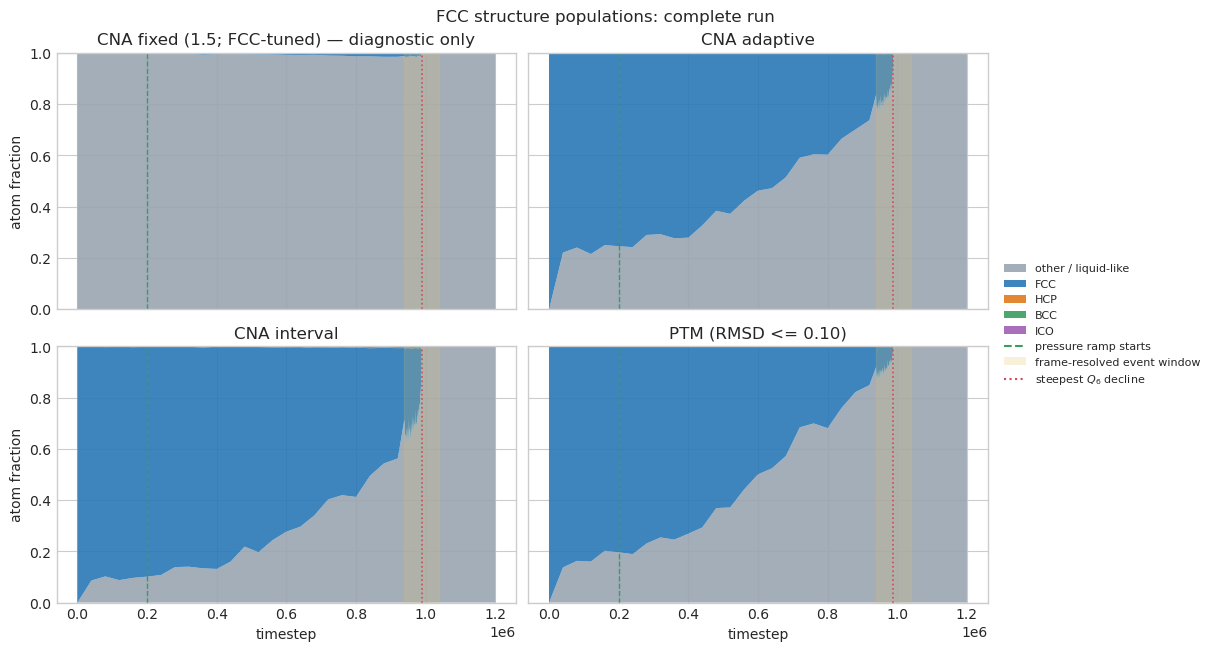

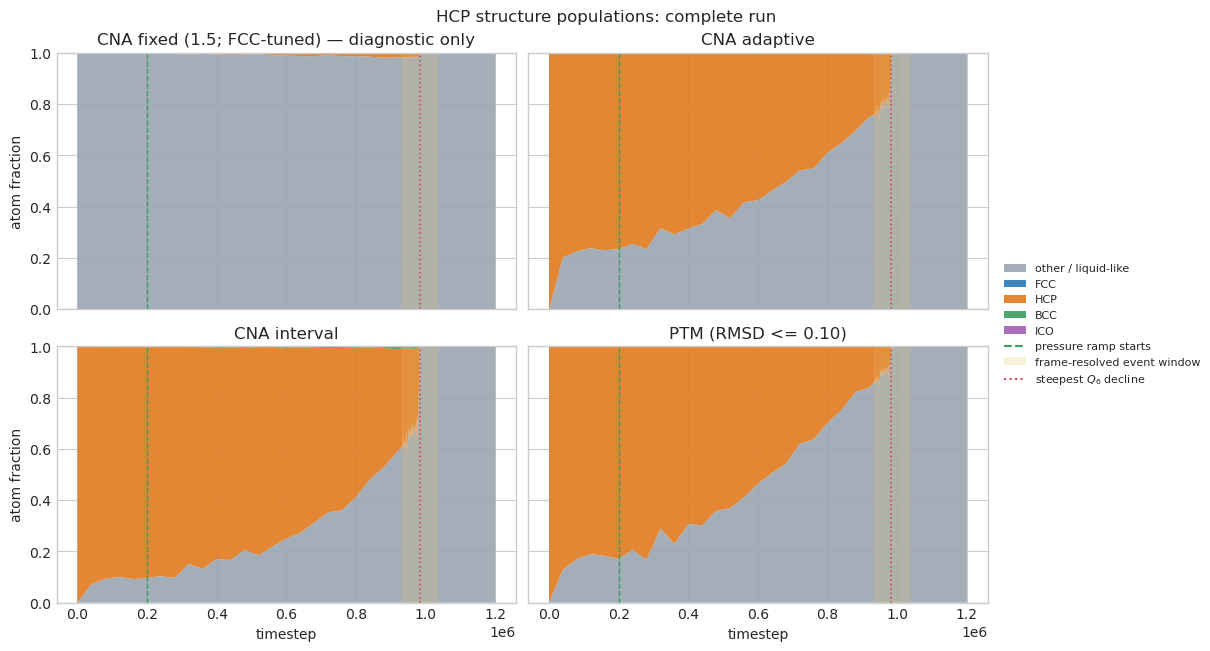

In [6]:
classifier_columns = list(CLASSIFIER_FACTORIES)
population_long = particles.melt(id_vars=["run", "frame_index", "timestep", "atom_id", "x", "y", "z"],
    value_vars=classifier_columns, var_name="method", value_name="structure_id")
population_long["structure"] = population_long.structure_id.map(STRUCTURE_NAMES).fillna("unknown")
fractions = population_long.groupby(["run", "timestep", "method", "structure"], observed=True).size().rename("count").reset_index()
fractions["fraction"] = fractions["count"] / fractions.groupby(["run", "timestep", "method"])["count"].transform("sum")

def plot_structure_fractions(run):
    config = RUNS[run]
    fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True, sharey=True, constrained_layout=True)
    run_data = fractions[fractions.run.eq(run)]
    for ax, method in zip(axes.flat, classifier_columns):
        wide = run_data[run_data.method.eq(method)].pivot(index="timestep", columns="structure", values="fraction").fillna(0).sort_index()
        order = [name for name in STRUCTURE_COLORS if name in wide]
        ax.stackplot(wide.index, *[wide[name] for name in order], labels=order,
                     colors=[STRUCTURE_COLORS[name] for name in order], alpha=0.9)
        ax.axvline(config["ramp_start_step"], color="#3a9d5d", ls="--", lw=1)
        if config["event_start_step"] is not None:
            ax.axvspan(config["event_start_step"], config["event_end_step"], color="#e9c46a", alpha=.18)
            ax.axvline(config["transition_step"], color="#d1495b", ls=":", lw=1.2)
        diagnostic = " — diagnostic only" if method in DIAGNOSTIC_CLASSIFIERS else ""
        ax.set_title(method + diagnostic); ax.set_ylim(0, 1); ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    axes[0, 0].set_ylabel("atom fraction"); axes[1, 0].set_ylabel("atom fraction")
    axes[1, 0].set_xlabel("timestep"); axes[1, 1].set_xlabel("timestep")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    handles += [Line2D([0], [0], color="#3a9d5d", ls="--", label="pressure ramp starts"),
                Patch(facecolor="#e9c46a", alpha=.25, label="frame-resolved event window"),
                Line2D([0], [0], color="#d1495b", ls=":", label="steepest $Q_6$ decline")]
    labels += ["pressure ramp starts", "frame-resolved event window", "steepest $Q_6$ decline"]
    fig.legend(handles, labels, loc="outside right center", frameon=False, fontsize=8)
    fig.suptitle(f"{run.upper()} structure populations: complete run")
    plt.show()
for run in RUNS:
    plot_structure_fractions(run)

## 5. Agreement: complete run and frame-resolved event

The primary consensus uses **adaptive CNA, interval CNA, and PTM**. The **2-of-3 expected-crystal** curve is a majority-support summary; **3-of-3 Other** marks atoms for which every primary geometric method has lost a crystalline assignment. The top row provides full-run context and the bottom row enlarges the every-frame transition window. The strict 99% line is reused as the classifier-collapse component of the liquid-reference definition.

These are operational method-consensus summaries, not statistical confidence bounds or ground truth. Fixed-cutoff CNA remains a scale-sensitive diagnostic.

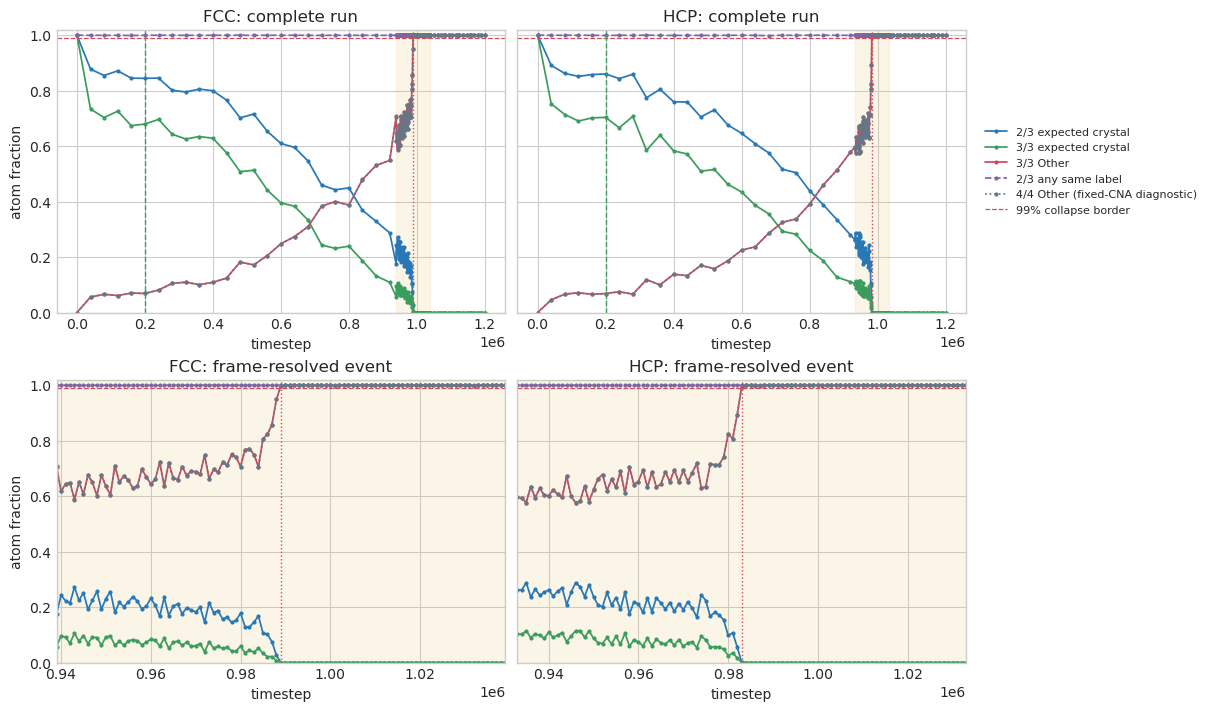

FCC pairwise disagreement (sample-weighted; fixed-cutoff CNA is diagnostic only)


,CNA fixed (1.5; FCC-tuned),CNA adaptive,CNA interval,PTM (RMSD <= 0.10)
CNA fixed (1.5; FCC-tuned),0.000,0.161,0.226,0.132
CNA adaptive,0.161,0.000,0.069,0.081
CNA interval,0.226,0.069,0.000,0.115
PTM (RMSD <= 0.10),0.132,0.081,0.115,0.000


HCP pairwise disagreement (sample-weighted; fixed-cutoff CNA is diagnostic only)


,CNA fixed (1.5; FCC-tuned),CNA adaptive,CNA interval,PTM (RMSD <= 0.10)
CNA fixed (1.5; FCC-tuned),0.000,0.169,0.237,0.139
CNA adaptive,0.169,0.000,0.072,0.086
CNA interval,0.237,0.072,0.000,0.120
PTM (RMSD <= 0.10),0.139,0.086,0.120,0.000


In [7]:
core_votes = particles[CORE_CLASSIFIERS].to_numpy(dtype=np.int8)
all_votes = particles[classifier_columns].to_numpy(dtype=np.int8)
expected_ids = particles.run.map({run: cfg["expected_id"] for run, cfg in RUNS.items()}).to_numpy()
particles["core_expected_votes"] = (core_votes == expected_ids[:, None]).sum(axis=1)
particles["core_max_same_label_votes"] = np.stack(
    [(core_votes == i).sum(axis=1) for i in STRUCTURE_NAMES], axis=1
).max(axis=1)
particles["core_expected_2_of_3"] = particles.core_expected_votes.ge(2)
particles["core_expected_unanimous"] = particles.core_expected_votes.eq(3)
particles["core_unanimous_other"] = (core_votes == 0).all(axis=1)
particles["core_any_2_of_3"] = particles.core_max_same_label_votes.ge(2)
particles["all4_unanimous_other_diagnostic"] = (all_votes == 0).all(axis=1)
agreement_columns = ["core_expected_2_of_3", "core_expected_unanimous",
                     "core_unanimous_other", "core_any_2_of_3",
                     "all4_unanimous_other_diagnostic"]
agreement = particles.groupby(["run", "timestep"])[agreement_columns].mean().reset_index()

curve_styles = {
    "core_expected_2_of_3": ("2/3 expected crystal", "#2878b5", "-"),
    "core_expected_unanimous": ("3/3 expected crystal", "#3a9d5d", "-"),
    "core_unanimous_other": ("3/3 Other", "#d1495b", "-"),
    "core_any_2_of_3": ("2/3 any same label", "#8064a2", "--"),
    "all4_unanimous_other_diagnostic": ("4/4 Other (fixed-CNA diagnostic)", "#657786", ":"),
}
fig, axes = plt.subplots(2, len(RUNS), figsize=(12, 7), sharey=True, constrained_layout=True)
axes = np.atleast_2d(axes)
for column, run in enumerate(RUNS):
    config = RUNS[run]
    part = agreement[agreement.run.eq(run)].sort_values("timestep")
    for row, view in enumerate(["complete run", "frame-resolved event"]):
        ax = axes[row, column]
        for name, (label, color, linestyle) in curve_styles.items():
            ax.plot(part.timestep, part[name], marker="o", ms=2.0, lw=1.25,
                    color=color, ls=linestyle, label=label)
        ax.axhline(COMPLETE_COLLAPSE_THRESHOLD, color="#d1495b", ls="--", lw=.9,
                   label=f"{COMPLETE_COLLAPSE_THRESHOLD:.0%} collapse border")
        if row == 0:
            ax.axvline(config["ramp_start_step"], color="#3a9d5d", ls="--", lw=1)
        if config["event_start_step"] is not None:
            ax.axvspan(config["event_start_step"], config["event_end_step"], color="#e9c46a", alpha=.16)
            ax.axvline(config["transition_step"], color="#d1495b", ls=":", lw=1)
            if row == 1: ax.set_xlim(config["event_start_step"], config["event_end_step"])
        ax.set(title=f"{run.upper()}: {view}", xlabel="timestep", ylim=(0, 1.02))
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axes[0, 0].set_ylabel("atom fraction"); axes[1, 0].set_ylabel("atom fraction")
axes[0, -1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
plt.show()

def pairwise_disagreement(run):
    subset = particles[particles.run.eq(run)]
    return pd.DataFrame([[(subset[a] != subset[b]).mean() for b in classifier_columns] for a in classifier_columns],
                        index=classifier_columns, columns=classifier_columns)
for run in RUNS:
    print(f"{run.upper()} pairwise disagreement (sample-weighted; fixed-cutoff CNA is diagnostic only)")
    display(pairwise_disagreement(run).round(3))

## 6. Define and visibly reuse a strict empirical-liquid border

A structurally analyzed frame enters the empirical liquid reference only when it is after the detected $Q_6$ decline, at least **99%** of its atoms are unanimously `Other` according to the three primary classifiers, and its every-frame unwrapped MSD exceeds **$1.0\,\sigma^2$**. This is deliberately stricter than the previous 95% / $0.5\,\sigma^2$ rule.

The first frame satisfying this intersection is called the **strict-liquid onset** below. It is drawn explicitly in subsequent descriptor and C2ST plots. The definition combines complete geometric-classifier collapse with actual mobility, while remaining an operational reference rather than externally labelled ground truth.

Strict selection: unanimous Other >= 99%, unwrapped MSD >= 1.00 sigma^2, and at/after Q6 decline


,reference_frames,first_step,last_step,mean_core_unanimous_other,minimum_unwrapped_MSD
run,,,,,
fcc,70,989000,1200000,1.0,1.254
hcp,70,984000,1200000,1.0,2.412


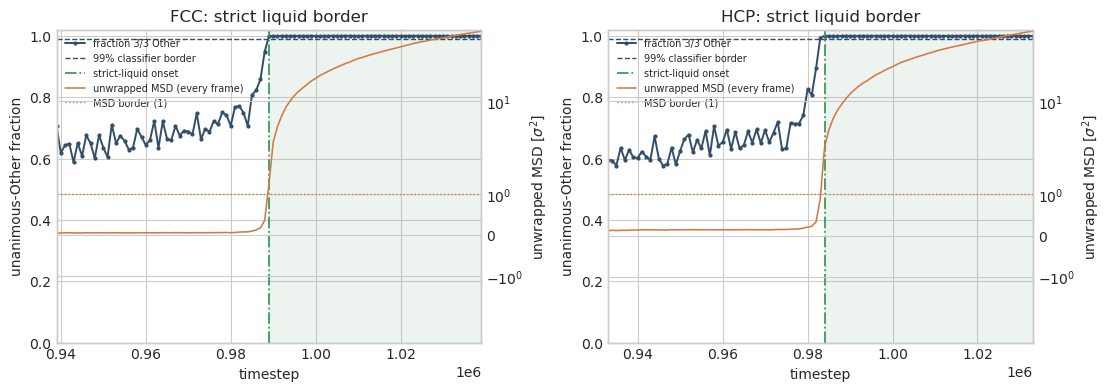

In [8]:
frame_diagnostics = agreement[["run", "timestep", "core_unanimous_other"]].merge(
    dynamics, on=["run", "timestep"], how="inner"
)
diagnostic_parts = []
for run, part in frame_diagnostics.groupby("run", sort=False):
    transition_step = RUNS[run].get("transition_step")
    late_cutoff = transition_step if transition_step is not None else part.timestep.quantile(2 / 3)
    diagnostic_parts.append(part.assign(transition_step=late_cutoff, after_decline=part.timestep.ge(late_cutoff)))
frame_diagnostics = pd.concat(diagnostic_parts, ignore_index=True)
frame_diagnostics["liquid_reference_frame"] = (
    frame_diagnostics.after_decline
    & frame_diagnostics.core_unanimous_other.ge(LIQUID_CONSENSUS_THRESHOLD)
    & frame_diagnostics.unwrapped_MSD.ge(LIQUID_MSD_THRESHOLD)
)
liquid_frames = frame_diagnostics[frame_diagnostics.liquid_reference_frame].copy()
liquid_keys = liquid_frames[["run", "timestep"]]
empirical_liquid = particles.merge(liquid_keys, on=["run", "timestep"], how="inner")
liquid_onset_steps = liquid_frames.groupby("run").timestep.min().to_dict()

print(f"Strict selection: unanimous Other >= {LIQUID_CONSENSUS_THRESHOLD:.0%}, "
      f"unwrapped MSD >= {LIQUID_MSD_THRESHOLD:.2f} sigma^2, and at/after Q6 decline")
if liquid_frames.empty:
    print("No frame passes the strict liquid-reference criteria. Inspect the diagnostic curves.")
else:
    reference_summary = liquid_frames.groupby("run").agg(
        reference_frames=("timestep", "size"), first_step=("timestep", "min"),
        last_step=("timestep", "max"), mean_core_unanimous_other=("core_unanimous_other", "mean"),
        minimum_unwrapped_MSD=("unwrapped_MSD", "min"),
    )
    display(reference_summary.round(3))

fig, axes = plt.subplots(1, len(RUNS), figsize=(11, 3.8), constrained_layout=True)
for ax, run in zip(np.atleast_1d(axes), RUNS):
    config = RUNS[run]
    part = frame_diagnostics[frame_diagnostics.run.eq(run)].sort_values("timestep")
    chosen = part[part.liquid_reference_frame]
    ax.plot(part.timestep, part.core_unanimous_other, color="#334e68", lw=1.4, marker="o", ms=2,
            label="fraction 3/3 Other")
    ax.axhline(LIQUID_CONSENSUS_THRESHOLD, color="#334e68", ls="--", lw=1,
               label=f"{LIQUID_CONSENSUS_THRESHOLD:.0%} classifier border")
    if config["event_start_step"] is not None:
        ax.set_xlim(config["event_start_step"], config["event_end_step"])
    if run in liquid_onset_steps:
        ax.axvline(liquid_onset_steps[run], color="#3a9d5d", ls="-.", lw=1.3,
                   label="strict-liquid onset")
        ax.axvspan(liquid_onset_steps[run], config["event_end_step"], color="#70a37f", alpha=.12)
    mobility_ax = ax.twinx()
    mobility_start = config["event_start_step"] if config["event_start_step"] is not None else part.timestep.min()
    mobility_end = config["event_end_step"] if config["event_end_step"] is not None else part.timestep.max()
    full_mobility = dynamics[dynamics.run.eq(run) & dynamics.timestep.between(mobility_start, mobility_end)]
    mobility_ax.plot(full_mobility.timestep, full_mobility.unwrapped_MSD, color="#d17a45", lw=1.15,
                     label="unwrapped MSD (every frame)")
    mobility_ax.axhline(LIQUID_MSD_THRESHOLD, color="#d17a45", ls=":", lw=1,
                        label=f"MSD border ({LIQUID_MSD_THRESHOLD:g})")
    mobility_ax.set_yscale("symlog")
    ax.set(title=f"{run.upper()}: strict liquid border", xlabel="timestep",
           ylabel="unanimous-Other fraction", ylim=(0, 1.02))
    mobility_ax.set_ylabel(r"unwrapped MSD [$\sigma^2$]")
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    handles1, labels1 = ax.get_legend_handles_labels(); handles2, labels2 = mobility_ax.get_legend_handles_labels()
    ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=False, fontsize=7)
plt.show()

## 7. Steinhardt spaces, reference distributions, and jump duration

The distribution-space panels show the complete coarse trajectory plus the every-frame melting window. Connected colored points are per-frame centroids; outlined ellipses show representative 68% per-atom spreads. The star is the perfect starting crystal, gray is the periodic ideal gas, amber is the strict empirical liquid, and the green `X` marks the first frame passing the strict liquid border.

The following frame-resolved plot then exposes every intermediate event frame, measures the 10–90% duration of the Lechner–Dellago mean-$q_6$ change, and reports the largest single-frame displacement in averaged $q_4/q_6$ space. Its horizontal range is the measured 10–90% interval plus five stored frames on either side, rather than the full 100,000-step analysis window.

> **Runtime note.** `Order 4 vertex memory scaled up to 16` is a harmless message from the Voronoi backend: it enlarged an internal cell-vertex buffer for the random reference. It does not indicate bad particle data or a failed calculation.

In [9]:
def descriptor_reference(n_particles=RANDOM_REFERENCE_PARTICLES):
    length = float(n_particles ** (1 / 3)); box = freud.box.Box.cube(length)
    positions = RNG.uniform(-length / 2, length / 2, size=(n_particles, 3)).astype(np.float32)
    voronoi = freud.locality.Voronoi().compute((box, positions)); output = {}
    for style, options in DESCRIPTOR_STYLES.items():
        neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
        suffix = style.lower().replace("-", "_")
        for prefix, wl in [("q", False), ("w", True)]:
            op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"], wl=wl, wl_normalize=wl)
            op.compute((box, positions), neighbors=neighbors)
            output[f"{prefix}4_{suffix}"] = op.particle_order[:, 0]
            output[f"{prefix}6_{suffix}"] = op.particle_order[:, 1]
    return pd.DataFrame(output)

def perfect_crystal_system(run, n_cells=6, density=1.2):
    if run == "fcc":
        a = (4 / density) ** (1 / 3)
        cell_lengths = np.array([a, a, a])
        basis = np.array([[0, 0, 0], [.5, .5, 0], [.5, 0, .5], [0, .5, .5]])
    elif run == "hcp":
        a = (np.sqrt(2) / density) ** (1 / 3)
        cell_lengths = np.array([a, np.sqrt(3) * a, np.sqrt(8 / 3) * a])
        basis = np.array([[0, 0, 0], [.5, .5, 0], [.5, 5 / 6, .5], [0, 1 / 3, .5]])
    else:
        raise ValueError(f"Unknown crystal: {run}")
    positions = np.concatenate([
        (np.array([i, j, k]) + basis) * cell_lengths
        for i in range(n_cells) for j in range(n_cells) for k in range(n_cells)
    ]).astype(np.float32)
    box_lengths = n_cells * cell_lengths
    return freud.box.Box(*box_lengths), positions

def perfect_crystal_references():
    rows = []
    for run in RUNS:
        box, positions = perfect_crystal_system(run)
        voronoi = freud.locality.Voronoi().compute((box, positions))
        row = {"run": run}
        for style, options in DESCRIPTOR_STYLES.items():
            neighbors = voronoi.nlist if options["weighted"] else {"num_neighbors": 12}
            suffix = style.lower().replace("-", "_")
            for prefix, wl in [("q", False), ("w", True)]:
                op = freud.order.Steinhardt(l=[4, 6], average=options["average"], weighted=options["weighted"],
                                            wl=wl, wl_normalize=wl)
                op.compute((box, positions), neighbors=neighbors)
                row[f"{prefix}4_{suffix}"] = float(np.nanmean(op.particle_order[:, 0]))
                row[f"{prefix}6_{suffix}"] = float(np.nanmean(op.particle_order[:, 1]))
        rows.append(row)
    return pd.DataFrame(rows).set_index("run")

random_reference = descriptor_reference()
perfect_reference = perfect_crystal_references()
display(random_reference.describe().loc[["mean", "std"]].round(4))
display(perfect_reference.round(4))

Order 4 vertex memory scaled up to 16


,q4_standard,q6_standard,w4_standard,w6_standard,q4_lechner_dellago,q6_lechner_dellago,w4_lechner_dellago,w6_lechner_dellago,q4_voronoi_facet,q6_voronoi_facet,w4_voronoi_facet,w6_voronoi_facet
mean,0.2826,0.2835,0.0257,-0.0192,0.0950,0.0952,0.0219,0.0003,0.3482,0.3525,0.0408,-0.0317
std,0.0638,0.0543,0.0665,0.0406,0.0249,0.0206,0.0677,0.0415,0.0801,0.0720,0.0665,0.0386


,q4_standard,q6_standard,w4_standard,w6_standard,q4_lechner_dellago,q6_lechner_dellago,w4_lechner_dellago,w6_lechner_dellago,q4_voronoi_facet,q6_voronoi_facet,w4_voronoi_facet,w6_voronoi_facet
run,,,,,,,,,,,,
fcc,0.1909,0.5745,-0.1593,-0.0132,0.1909,0.5745,-0.1593,-0.0132,0.1909,0.5745,-0.1593,-0.0132
hcp,0.0972,0.4848,0.1341,-0.0124,0.0972,0.4848,0.1341,-0.0124,0.0972,0.4848,0.1341,-0.0124


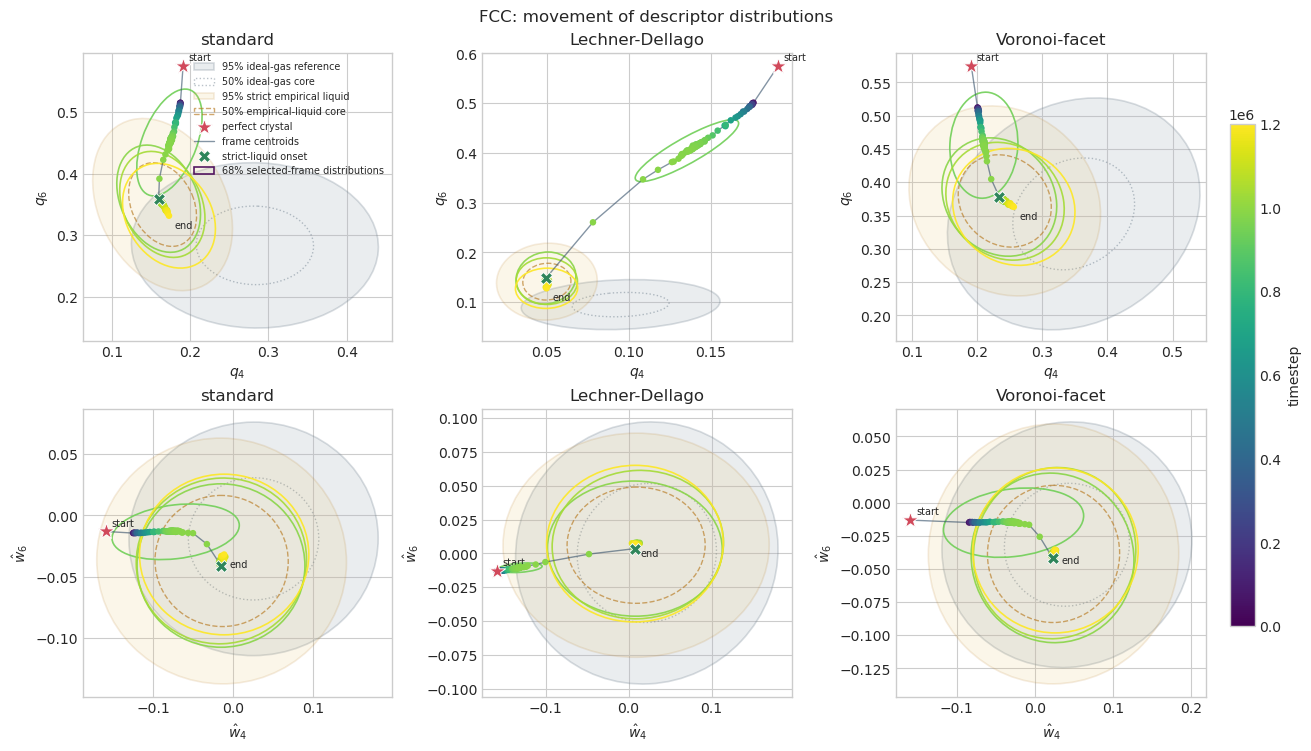

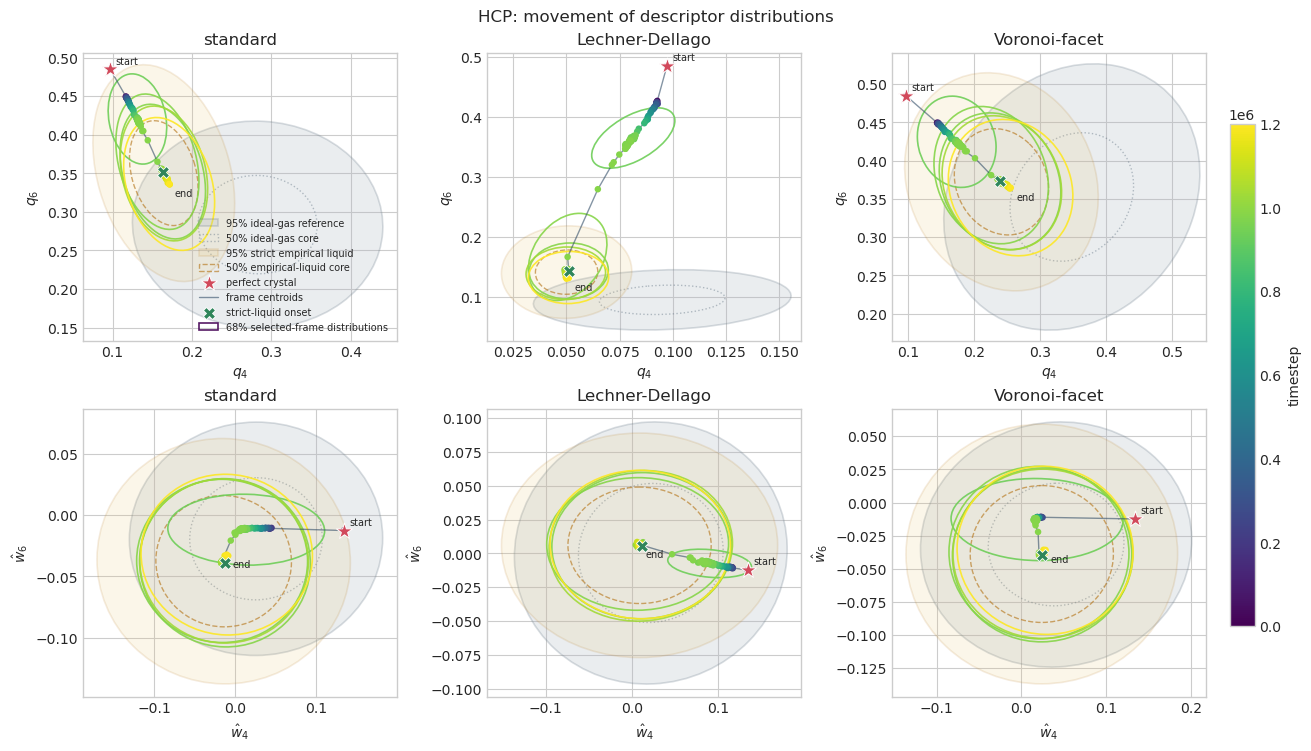

In [10]:
def add_distribution_ellipse(ax, x, y, coverage, *, facecolor, edgecolor, alpha, label=None, lw=1.2, linestyle="-"):
    points = np.column_stack([x, y]); points = points[np.isfinite(points).all(axis=1)]
    if len(points) < 3:
        return
    center = points.mean(axis=0); covariance = np.cov(points, rowvar=False)
    inverse = np.linalg.pinv(covariance)
    d2 = np.einsum("ni,ij,nj->n", points - center, inverse, points - center)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance); order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * np.sqrt(np.maximum(eigenvalues, 0) * np.quantile(d2, coverage))
    ax.add_patch(Ellipse(center, width, height, angle=angle, facecolor=facecolor, edgecolor=edgecolor,
                         alpha=alpha, lw=lw, linestyle=linestyle, label=label))

def representative_ellipse_steps(run, available_steps):
    config = RUNS[run]
    candidates = [available_steps.min(), config["event_start_step"], config["transition_step"],
                  liquid_onset_steps.get(run), config["event_end_step"], available_steps.max()]
    return np.unique([available_steps[np.abs(available_steps - step).argmin()]
                      for step in candidates if step is not None])

def plot_descriptor_spaces(run):
    run_data = particles[particles.run.eq(run)]
    steps = np.sort(run_data.timestep.unique())
    ellipse_steps = representative_ellipse_steps(run, steps)
    norm = plt.Normalize(steps.min(), steps.max()); cmap = plt.cm.viridis
    fig, axes = plt.subplots(2, 3, figsize=(13, 7.4), constrained_layout=True)
    mappable = None

    for column, (style, _) in enumerate(DESCRIPTOR_STYLES.items()):
        suffix = style.lower().replace("-", "_")
        for row, prefix in enumerate(["q", "w"]):
            ax = axes[row, column]; xcol, ycol = f"{prefix}4_{suffix}", f"{prefix}6_{suffix}"
            add_distribution_ellipse(ax, random_reference[xcol], random_reference[ycol], 0.95,
                                     facecolor="#aeb8c2", edgecolor="#657786", alpha=0.25,
                                     label="95% ideal-gas reference")
            add_distribution_ellipse(ax, random_reference[xcol], random_reference[ycol], 0.50,
                                     facecolor="none", edgecolor="#657786", alpha=0.45, lw=1.0,
                                     linestyle=":", label="50% ideal-gas core")
            dense_liquid = empirical_liquid[empirical_liquid.run.eq(run)]
            if not dense_liquid.empty:
                add_distribution_ellipse(ax, dense_liquid[xcol], dense_liquid[ycol], 0.95,
                                         facecolor="#e9c46a", edgecolor="#b7791f", alpha=0.14,
                                         label="95% strict empirical liquid")
                add_distribution_ellipse(ax, dense_liquid[xcol], dense_liquid[ycol], 0.50,
                                         facecolor="none", edgecolor="#b7791f", alpha=0.65, lw=1.0,
                                         linestyle="--", label="50% empirical-liquid core")
            perfect = perfect_reference.loc[run]
            ax.scatter(perfect[xcol], perfect[ycol], marker="*", s=150, color="#d1495b",
                       edgecolor="white", linewidth=.7, zorder=6, label="perfect crystal")

            centroids = run_data.groupby("timestep")[[xcol, ycol]].mean().sort_index()
            ax.plot(centroids[xcol], centroids[ycol], color="#334e68", lw=1.0, alpha=0.6,
                    label="frame centroids")
            mappable = ax.scatter(centroids[xcol], centroids[ycol], c=centroids.index, cmap=cmap, norm=norm,
                                  s=22, edgecolor="none", zorder=4)
            onset = liquid_onset_steps.get(run)
            if onset in centroids.index:
                ax.scatter(centroids.loc[onset, xcol], centroids.loc[onset, ycol], marker="X", s=75,
                           color="#2f855a", edgecolor="white", lw=.6, zorder=7, label="strict-liquid onset")

            for ellipse_index, step in enumerate(ellipse_steps):
                cloud = run_data[run_data.timestep.eq(step)]
                add_distribution_ellipse(ax, cloud[xcol], cloud[ycol], 0.68, facecolor="none",
                                         edgecolor=cmap(norm(step)), alpha=0.9, lw=1.2,
                                         label="68% selected-frame distributions" if ellipse_index == 0 else None)
            ax.annotate("start", (centroids.iloc[0][xcol], centroids.iloc[0][ycol]),
                        xytext=(4, 4), textcoords="offset points", fontsize=7)
            ax.annotate("end", (centroids.iloc[-1][xcol], centroids.iloc[-1][ycol]),
                        xytext=(4, -9), textcoords="offset points", fontsize=7)
            symbol = "q" if prefix == "q" else r"\hat w"
            ax.set(xlabel=fr"${symbol}_4$", ylabel=fr"${symbol}_6$", title=style)

    fig.colorbar(mappable, ax=axes, label="timestep", shrink=0.78, pad=0.02)
    axes[0, 0].legend(loc="best", fontsize=7, frameon=False)
    fig.suptitle(f"{run.upper()}: movement of descriptor distributions")
    plt.show()

for run in RUNS:
    plot_descriptor_spaces(run)

,run,early_mean_q6,late_mean_q6,q6_10_percent_step,q6_90_percent_step,q6_10_to_90_timesteps,q6_10_to_90_dump_intervals,largest_q_step,largest_delta_q
0,fcc,0.4148,0.1427,982000,989000,7000,7,989000,0.1156
1,hcp,0.3633,0.1431,979000,984000,5000,5,983000,0.1138


Seven consecutive stored frames around each largest averaged-q step:


,run,timestep,q4_lechner_dellago,q6_lechner_dellago,q6_progress_raw,delta_averaged_q,core_unanimous_other,unwrapped_MSD
0,fcc,986000,0.1178,0.3661,0.1791,0.0178,0.8228,0.1280
1,fcc,987000,0.1087,0.3471,0.2490,0.0211,0.8580,0.1792
2,fcc,988000,0.0782,0.2606,0.5666,0.0917,0.9488,0.3584
3,fcc,989000,0.0496,0.1486,0.9783,0.1156,0.9988,1.2544
4,fcc,990000,0.0500,0.1441,0.9948,0.0045,0.9998,2.8090
5,fcc,991000,0.0498,0.1446,0.9928,0.0006,0.9992,4.5567
6,fcc,992000,0.0501,0.1428,0.9996,0.0019,0.9995,6.3759
7,hcp,980000,0.0722,0.3245,0.1761,0.0131,0.8250,0.2066
8,hcp,981000,0.0714,0.3202,0.1957,0.0044,0.8072,0.2292
9,hcp,982000,0.0648,0.2796,0.3802,0.0411,0.8935,0.3315


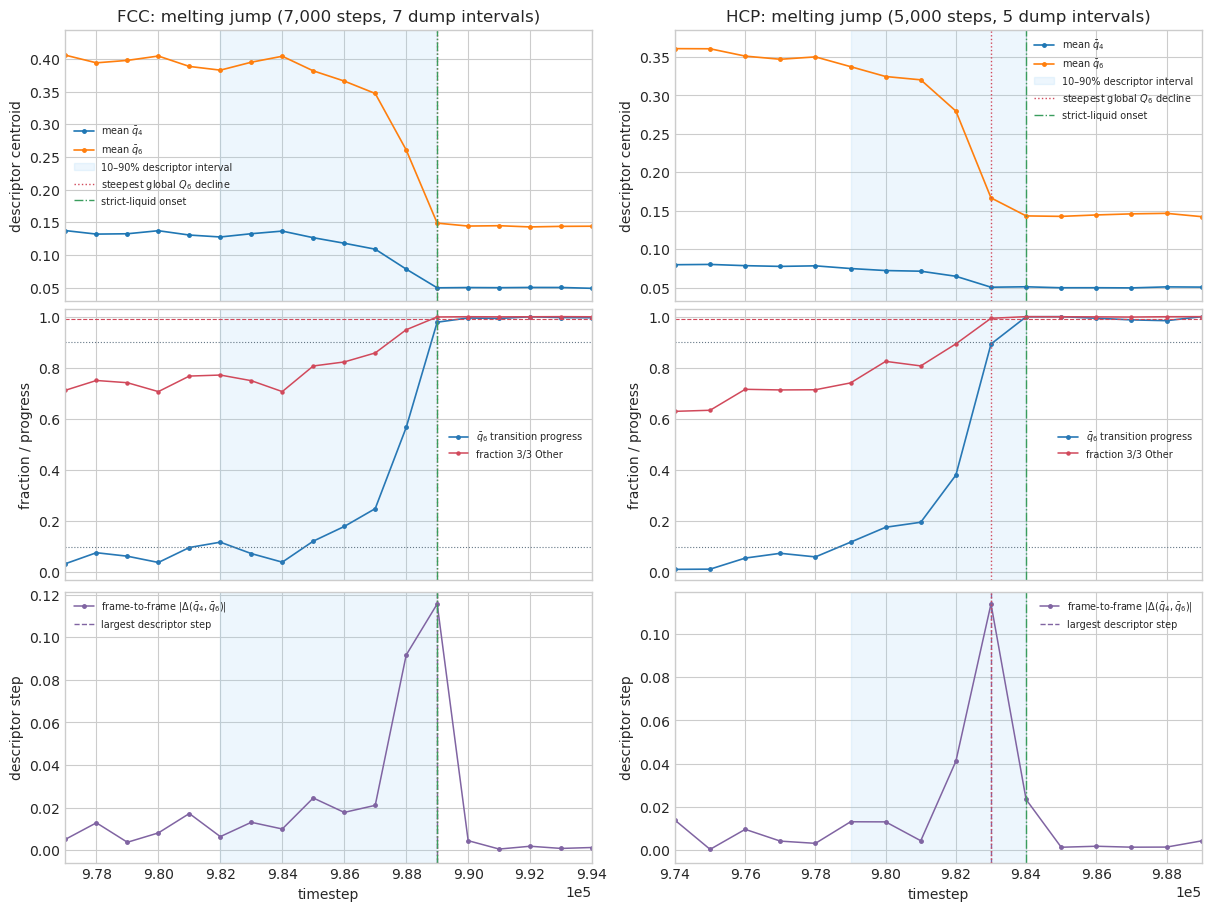

In [11]:
qcols_speed = ["q4_lechner_dellago", "q6_lechner_dellago"]
event_centroids = (particles.groupby(["run", "timestep"])[qcols_speed].mean().reset_index()
                   .merge(agreement[["run", "timestep", "core_unanimous_other"]],
                          on=["run", "timestep"], how="left")
                   .merge(dynamics[["run", "timestep", "unwrapped_MSD"]],
                          on=["run", "timestep"], how="left"))
event_centroids = pd.concat([
    event_centroids[event_centroids.run.eq(run) & event_centroids.timestep.between(
        config["event_start_step"], config["event_end_step"])]
    for run, config in RUNS.items()
], ignore_index=True)

def first_progress_crossing(table, level):
    crossed = table[table.q6_progress.ge(level)]
    if not crossed.empty:
        return int(crossed.iloc[0].timestep)
    nearest = (table.q6_progress - level).abs().idxmin()
    return int(table.loc[nearest, "timestep"])

jump_summaries, jump_details = [], []
fig, axes = plt.subplots(3, len(RUNS), figsize=(12, 9), sharex="col", constrained_layout=True)
axes = np.atleast_2d(axes)
for column, run in enumerate(RUNS):
    config = RUNS[run]
    part = event_centroids[event_centroids.run.eq(run)].sort_values("timestep").copy().reset_index(drop=True)
    center = config["transition_step"]
    early_q6 = part.loc[part.timestep.between(center - 45_000, center - 25_000),
                        "q6_lechner_dellago"].median()
    late_q6 = part.loc[part.timestep.between(center + 25_000, center + 45_000),
                       "q6_lechner_dellago"].median()
    part["q6_progress_raw"] = (early_q6 - part.q6_lechner_dellago) / (early_q6 - late_q6)
    transition_band = part.timestep.between(center - 25_000, center + 25_000)
    part["q6_progress"] = np.nan
    part.loc[transition_band, "q6_progress"] = np.maximum.accumulate(
        part.loc[transition_band, "q6_progress_raw"].clip(0, 1).to_numpy())
    part["delta_averaged_q"] = np.sqrt(part[qcols_speed].diff().pow(2).sum(axis=1))
    band = part[transition_band]
    step10 = first_progress_crossing(band, .10)
    step90 = first_progress_crossing(band, .90)
    zoom_start = max(int(part.timestep.min()), step10 - 5 * config["dump_every"])
    zoom_end = min(int(part.timestep.max()), step90 + 5 * config["dump_every"])
    largest_index = int(band.delta_averaged_q.idxmax())
    largest = part.loc[largest_index]
    jump_summaries.append({"run": run, "early_mean_q6": early_q6, "late_mean_q6": late_q6,
                           "q6_10_percent_step": step10, "q6_90_percent_step": step90,
                           "q6_10_to_90_timesteps": step90 - step10,
                           "q6_10_to_90_dump_intervals": (step90 - step10) // config["dump_every"],
                           "largest_q_step": int(largest.timestep),
                           "largest_delta_q": largest.delta_averaged_q})
    detail = part.loc[max(0, largest_index - 3):min(len(part) - 1, largest_index + 3),
                      ["run", "timestep", *qcols_speed, "q6_progress_raw", "delta_averaged_q",
                       "core_unanimous_other", "unwrapped_MSD"]]
    jump_details.append(detail)

    axes[0, column].plot(part.timestep, part.q4_lechner_dellago, marker="o", ms=2.5,
                         lw=1.2, label=r"mean $\bar q_4$")
    axes[0, column].plot(part.timestep, part.q6_lechner_dellago, marker="o", ms=2.5,
                         lw=1.2, label=r"mean $\bar q_6$")
    axes[1, column].plot(part.timestep, part.q6_progress_raw.clip(0, 1), marker="o", ms=2.5,
                         color="#2878b5", lw=1.2, label=r"$\bar q_6$ transition progress")
    axes[1, column].plot(part.timestep, part.core_unanimous_other, marker="o", ms=2.2,
                         color="#d1495b", lw=1.1, label="fraction 3/3 Other")
    axes[1, column].axhline(.10, color="#657786", ls=":", lw=.8)
    axes[1, column].axhline(.90, color="#657786", ls=":", lw=.8)
    axes[1, column].axhline(COMPLETE_COLLAPSE_THRESHOLD, color="#d1495b", ls="--", lw=.8)
    axes[2, column].plot(part.timestep, part.delta_averaged_q, marker="o", ms=2.5,
                         color="#8064a2", lw=1.1, label=r"frame-to-frame $|\Delta(\bar q_4,\bar q_6)|$")
    axes[2, column].axvline(int(largest.timestep), color="#8064a2", ls="--", lw=1,
                            label="largest descriptor step")
    for row in range(3):
        axes[row, column].axvspan(step10, step90, color="#90cdf4", alpha=.16,
                                  label="10–90% descriptor interval" if row == 0 else None)
        axes[row, column].axvline(center, color="#d1495b", ls=":", lw=1,
                                  label="steepest global $Q_6$ decline" if row == 0 else None)
        if run in liquid_onset_steps:
            axes[row, column].axvline(liquid_onset_steps[run], color="#3a9d5d", ls="-.", lw=1,
                                      label="strict-liquid onset" if row == 0 else None)
        axes[row, column].set_xlim(zoom_start, zoom_end)
        axes[row, column].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
        axes[row, column].legend(frameon=False, fontsize=7)
    axes[0, column].set_title(f"{run.upper()}: melting jump ({step90 - step10:,} steps, "
                              f"{(step90 - step10) // config['dump_every']} dump intervals)")
    axes[0, column].set_ylabel("descriptor centroid")
    axes[1, column].set_ylabel("fraction / progress"); axes[1, column].set_ylim(-.03, 1.03)
    axes[2, column].set_ylabel("descriptor step"); axes[2, column].set_xlabel("timestep")

descriptor_jump_summary = pd.DataFrame(jump_summaries)
display(descriptor_jump_summary.round(4))
print("Seven consecutive stored frames around each largest averaged-q step:")
display(pd.concat(jump_details, ignore_index=True).round(4))
plt.show()

## 8. When the geometric classifiers fail, is q-space already liquid-like?

A classifier two-sample test (C2ST) compares a five-frame window around each analyzed state with seven strict late-liquid frames from the **other** run. Every event state is tested because every event frame is now present; outside the event, only the coarse overview states are tested. Cross-validation holds out complete frames rather than random atoms. Each fold explicitly contains at least one target frame and one liquid-reference frame, so its ROC AUC is always defined.

An AUC near 0.5 means that the chosen descriptor set cannot reliably separate that state from an independent liquid reference; it does not prove equality. The interval is a 2,000-resample bootstrap over held-out-frame folds. Each diagnostic is shown twice: first as complete-run context and then as a focused melting-event path. The focused time range is inherited from chapter 7's measured 10–90% intervals plus five stored frames of padding. Strict-liquid onset and the 99% classifier-collapse border are marked explicitly.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

C2ST_ATOMS_PER_FRAME = 400
C2ST_WINDOW_FRAMES = 5
C2ST_REFERENCE_FRAMES = 7
C2ST_BOOTSTRAPS = 2000
C2ST_FEATURES = OrderedDict({
    "standard q": ["q4_standard", "q6_standard"],
    "averaged q": ["q4_lechner_dellago", "q6_lechner_dellago"],
    "all q": [f"q{l}_{suffix}" for suffix in ["standard", "lechner_dellago", "voronoi_facet"] for l in [4, 6]],
    "q + w": [f"{prefix}{l}_{suffix}" for suffix in ["standard", "lechner_dellago", "voronoi_facet"]
              for prefix in ["q", "w"] for l in [4, 6]],
})
ALL_C2ST_COLUMNS = list(dict.fromkeys(column for columns in C2ST_FEATURES.values() for column in columns))

def evenly_spaced(values, count):
    values = np.sort(np.unique(values))
    return values[np.unique(np.rint(np.linspace(0, len(values) - 1, min(count, len(values)))).astype(int))]

def sample_complete_frames(table, steps, seed):
    pieces = []
    for offset, step in enumerate(steps):
        frame = table[table.timestep.eq(step)]
        pieces.append(frame.sample(n=min(C2ST_ATOMS_PER_FRAME, len(frame)), random_state=seed + offset))
    return pd.concat(pieces, ignore_index=True)

def c2st_with_frame_holdout(dataset, columns, seed):
    finite = dataset[columns].notna().all(axis=1)
    data = dataset.loc[finite]
    X = data[columns].to_numpy(); y = data["is_target"].to_numpy(dtype=np.int8)
    groups = (data.run.astype(str) + ":" + data.timestep.astype(str)).to_numpy()
    target_groups = np.unique(groups[y == 1]); reference_groups = np.unique(groups[y == 0])
    n_splits = min(5, len(target_groups), len(reference_groups))
    rng = np.random.default_rng(seed)
    target_folds = np.array_split(rng.permutation(target_groups), n_splits)
    reference_folds = np.array_split(rng.permutation(reference_groups), n_splits)
    fold_aucs = []
    for target_fold, reference_fold in zip(target_folds, reference_folds):
        test_groups = np.concatenate([target_fold, reference_fold])
        test_mask = np.isin(groups, test_groups)
        test = np.flatnonzero(test_mask); train = np.flatnonzero(~test_mask)
        model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, C=1.0))
        model.fit(X[train], y[train])
        fold_aucs.append(roc_auc_score(y[test], model.predict_proba(X[test])[:, 1]))
    fold_aucs = np.asarray(fold_aucs)
    rng = np.random.default_rng(seed + 10_000)
    boot = rng.choice(fold_aucs, size=(C2ST_BOOTSTRAPS, len(fold_aucs)), replace=True).mean(axis=1)
    return fold_aucs.mean(), *np.quantile(boot, [0.025, 0.975])

liquid_samples = {}
for run in RUNS:
    reference_steps = evenly_spaced(empirical_liquid.loc[empirical_liquid.run.eq(run), "timestep"],
                                    C2ST_REFERENCE_FRAMES)
    liquid_samples[run] = sample_complete_frames(empirical_liquid[empirical_liquid.run.eq(run)],
                                                 reference_steps, 3000)

separability_rows = []
for run_index, run in enumerate(RUNS):
    opposite_run = next(other for other in RUNS if other != run)
    run_data = particles[particles.run.eq(run)]
    steps = np.sort(run_data.timestep.unique())
    for step_index, step in enumerate(steps):
        start = np.clip(step_index - C2ST_WINDOW_FRAMES // 2, 0, max(0, len(steps) - C2ST_WINDOW_FRAMES))
        local_steps = steps[start:start + C2ST_WINDOW_FRAMES]
        target = sample_complete_frames(run_data, local_steps, 1000 + 100 * run_index + step_index).assign(is_target=1)
        reference = liquid_samples[opposite_run].assign(is_target=0)
        dataset = pd.concat([target, reference], ignore_index=True)
        for feature_index, (feature_set, columns) in enumerate(C2ST_FEATURES.items()):
            auc, low, high = c2st_with_frame_holdout(dataset, columns, 7000 + 100 * step_index + feature_index)
            separability_rows.append({"run": run, "timestep": step, "feature_set": feature_set,
                                       "auc": auc, "auc_low": low, "auc_high": high,
                                       "liquid_reference_run": opposite_run})
    print(f"{run.upper()}: frame-held-out C2ST complete for {len(steps)} states")
q_separability = pd.DataFrame(separability_rows)
display(q_separability.groupby(["run", "feature_set"]).agg(
    minimum_AUC=("auc", "min"), final_AUC=("auc", "last")
).round(3))

event_rows = []
for run in RUNS:
    center = RUNS[run]["transition_step"]
    part = q_separability[q_separability.run.eq(run) & q_separability.feature_set.eq("averaged q")]
    for offset in [-20_000, -10_000, -5_000, -2_000, -1_000, 0, 1_000, 2_000, 5_000, 10_000, 20_000, 40_000]:
        nearest = part.iloc[np.abs(part.timestep.to_numpy() - (center + offset)).argmin()]
        event_rows.append(nearest.to_dict() | {"offset_from_Q6_decline": offset,
                           "offset_from_strict_liquid": nearest.timestep - liquid_onset_steps.get(run, np.nan)})
event_q_summary = pd.DataFrame(event_rows).drop_duplicates(["run", "timestep"])
display(event_q_summary[["run", "timestep", "offset_from_Q6_decline", "offset_from_strict_liquid",
                         "auc", "auc_low", "auc_high"]].round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, constrained_layout=True)
run_colors = {"fcc": "#2878b5", "hcp": "#e07a1f"}
for ax, feature_set in zip(axes.flat, C2ST_FEATURES):
    for run in RUNS:
        part = q_separability[q_separability.run.eq(run) & q_separability.feature_set.eq(feature_set)].sort_values("timestep")
        ax.fill_between(part.timestep, part.auc_low, part.auc_high, color=run_colors[run], alpha=0.12)
        ax.plot(part.timestep, part.auc, color=run_colors[run], lw=1.3, marker="o", ms=1.8, label=run.upper())
        if run in liquid_onset_steps:
            ax.axvline(liquid_onset_steps[run], color=run_colors[run], ls=":", lw=1)
    ax.axhline(0.50, color="#657786", ls=":", lw=1); ax.axhline(0.55, color="#657786", ls="--", lw=.8)
    ax.set(title=feature_set, ylim=(0.45, 1.02)); ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
for ax in axes[-1]: ax.set_xlabel("timestep")
for ax in axes[:, 0]: ax.set_ylabel("AUC vs other-run strict liquid")
axes[0, 0].legend(frameon=False); plt.show()

c2st_zoom_start = int(descriptor_jump_summary.q6_10_percent_step.min()
                      - 5 * min(config["dump_every"] for config in RUNS.values()))
c2st_zoom_end = int(descriptor_jump_summary.q6_90_percent_step.max()
                    + 5 * max(config["dump_every"] for config in RUNS.values()))
collapse_steps = {run: int(agreement[agreement.run.eq(run)
    & agreement.core_unanimous_other.ge(COMPLETE_COLLAPSE_THRESHOLD)].timestep.min()) for run in RUNS}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True, constrained_layout=True)
for ax, feature_set in zip(axes.flat, C2ST_FEATURES):
    for run in RUNS:
        part = q_separability[q_separability.run.eq(run)
            & q_separability.feature_set.eq(feature_set)
            & q_separability.timestep.between(c2st_zoom_start, c2st_zoom_end)].sort_values("timestep")
        ax.fill_between(part.timestep, part.auc_low, part.auc_high, color=run_colors[run], alpha=.12)
        ax.plot(part.timestep, part.auc, color=run_colors[run], lw=1.5, marker="o", ms=3, label=run.upper())
        collapse = part[part.timestep.eq(collapse_steps[run])]
        if not collapse.empty:
            ax.scatter(collapse.timestep, collapse.auc, marker="X", s=55, color=run_colors[run],
                       edgecolor="white", lw=.6, zorder=5)
        ax.axvline(liquid_onset_steps[run], color=run_colors[run], ls=":", lw=1)
    ax.axhline(.50, color="#657786", ls=":", lw=1); ax.axhline(.55, color="#657786", ls="--", lw=.8)
    ax.set(title=feature_set, xlim=(c2st_zoom_start, c2st_zoom_end), ylim=(.45, 1.02))
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
for ax in axes[-1]: ax.set_xlabel("timestep")
for ax in axes[:, 0]: ax.set_ylabel("AUC vs other-run strict liquid")
axes[0, 0].legend(frameon=False)
fig.suptitle("C2ST: focused melting-event path (X = first 99% classifier collapse)")
plt.show()

failure_map = q_separability.merge(agreement[["run", "timestep", "core_unanimous_other"]],
                                   on=["run", "timestep"], how="left")
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True, constrained_layout=True)
failure_norm = plt.Normalize(failure_map.timestep.min(), failure_map.timestep.max())
failure_mappable = None
for ax, feature_set in zip(axes.flat, C2ST_FEATURES):
    for run in RUNS:
        part = failure_map[failure_map.run.eq(run) & failure_map.feature_set.eq(feature_set)].sort_values("timestep")
        ax.plot(part.core_unanimous_other, part.auc, color=run_colors[run], alpha=.55, lw=1)
        failure_mappable = ax.scatter(part.core_unanimous_other, part.auc, c=part.timestep, cmap="viridis",
                   norm=failure_norm, s=14, edgecolor=run_colors[run], linewidth=.35, label=run.upper())
    ax.axvline(LIQUID_CONSENSUS_THRESHOLD, color="#657786", ls="--", lw=1)
    ax.axhline(0.55, color="#657786", ls=":", lw=1)
    ax.set(title=feature_set, xlim=(-.02, 1.02), ylim=(.45, 1.02))
    ax.text(.04, .48, "labels remain; q looks liquid-like", fontsize=7, color="#52606d")
    ax.text(.57, .94, "labels lost; q still distinguishable", fontsize=7, color="#52606d")
for ax in axes[-1]: ax.set_xlabel("fraction 3/3 Other")
for ax in axes[:, 0]: ax.set_ylabel("AUC vs other-run strict liquid")
axes[0, 0].legend(frameon=False); fig.colorbar(failure_mappable, ax=axes, label="timestep", shrink=.78); plt.show()

fig, axes = plt.subplots(len(RUNS), len(C2ST_FEATURES), figsize=(15, 7.2),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_2d(axes)
failure_zoom_norm = plt.Normalize(c2st_zoom_start, c2st_zoom_end)
failure_zoom_mappable = None
for row, run in enumerate(RUNS):
    for column, feature_set in enumerate(C2ST_FEATURES):
        ax = axes[row, column]
        part = failure_map[failure_map.run.eq(run) & failure_map.feature_set.eq(feature_set)
            & failure_map.timestep.between(c2st_zoom_start, c2st_zoom_end)].sort_values("timestep")
        ax.plot(part.core_unanimous_other, part.auc, color=run_colors[run], lw=1.4, alpha=.8)
        failure_zoom_mappable = ax.scatter(part.core_unanimous_other, part.auc, c=part.timestep,
            cmap="viridis", norm=failure_zoom_norm, s=30, edgecolor=run_colors[run], linewidth=.4)
        collapse = part[part.timestep.eq(collapse_steps[run])]
        if not collapse.empty:
            ax.scatter(collapse.core_unanimous_other, collapse.auc, marker="X", s=75,
                       color="#d1495b", edgecolor="white", lw=.7, zorder=6,
                       label="first 99% collapse" if row == 0 and column == 0 else None)
        onset = part[part.timestep.eq(liquid_onset_steps[run])]
        if not onset.empty:
            ax.scatter(onset.core_unanimous_other, onset.auc, marker="D", s=48,
                       color="#2f855a", edgecolor="white", lw=.7, zorder=6,
                       label="strict-liquid onset" if row == 0 and column == 0 else None)
        ax.axvline(COMPLETE_COLLAPSE_THRESHOLD, color="#657786", ls="--", lw=.8)
        ax.axhline(.55, color="#657786", ls=":", lw=.8)
        ax.set(xlim=(.55, 1.005), ylim=(.45, 1.02))
        if row == 0: ax.set_title(feature_set)
        if row == len(RUNS) - 1: ax.set_xlabel("fraction 3/3 Other")
        if column == 0: ax.set_ylabel(f"{run.upper()}\nAUC vs strict liquid")
axes[0, 0].legend(frameon=False, fontsize=7, loc="lower left")
fig.colorbar(failure_zoom_mappable, ax=axes, label="timestep", shrink=.78)
fig.suptitle("Focused classifier-failure paths through the melting event")
plt.show()

## 9. Inspect both the pre-collapse mismatch and the first complete classifier collapse

Two matched inspections are produced with identical $q$-space and spatial panels:

1. the last pre-collapse state with 50–99% unanimous `Other` for which averaged $q$ remains distinguishable from opposite-run strict liquid (bootstrap lower bound above 0.55);
2. the **first analyzed frame with at least 99% unanimous `Other`**, i.e. the first complete collapse of adaptive CNA, interval CNA, and PTM.

Highlighted atoms are unanimously `Other` and outside the opposite-run liquid's empirical 95% Mahalanobis contour. Comparing the two figures shows whether continuous orientational order and mobility collapse simultaneously with the geometric methods or only afterwards. `INSPECTION_STEPS` may override the automatic pre-collapse choice; the first-collapse frame is always selected automatically.

Last distinguishable pre-collapse state


,run,timestep,core_unanimous_other,auc,auc_low,auc_high
0,fcc,988000,0.949,0.794,0.617,0.972
1,hcp,982000,0.894,0.809,0.629,0.987


,run,timestep,fraction_3_of_3_other,fraction_residual_q_signal,unwrapped_MSD,passes_strict_liquid_border
0,fcc,988000,0.949,0.62,0.358,False
1,hcp,982000,0.894,0.70,0.331,False


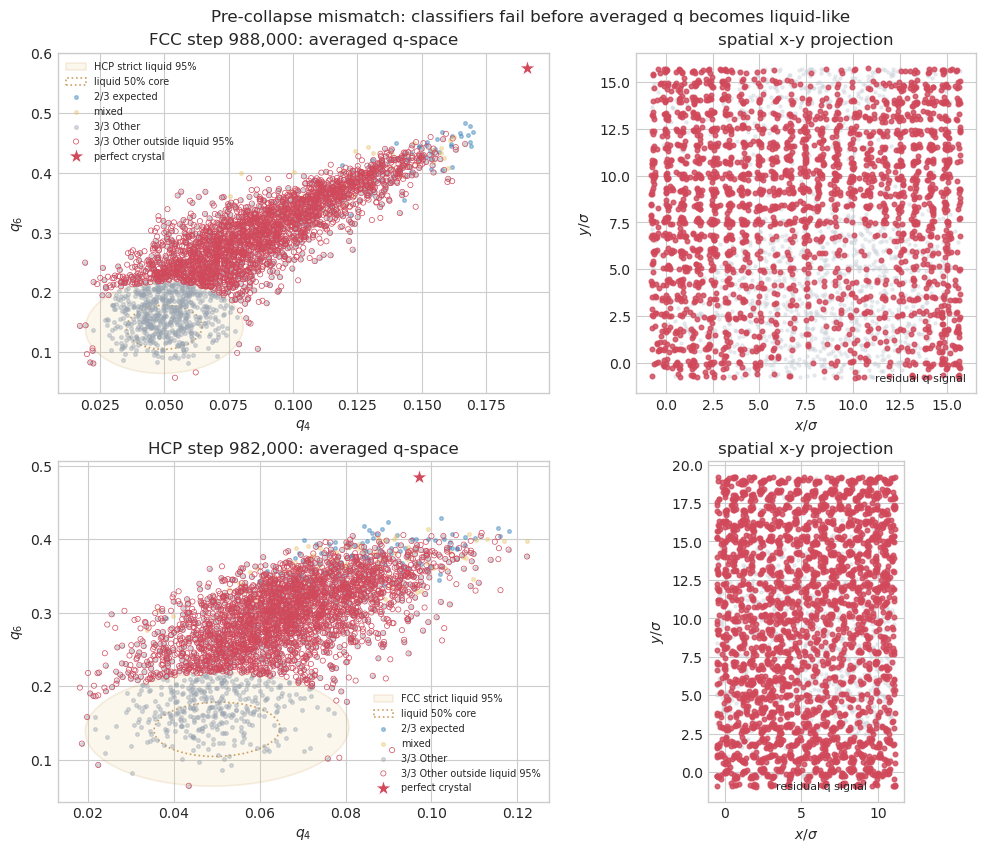

First frame at or above 99% unanimous Other


,run,timestep,core_unanimous_other,auc,auc_low,auc_high
0,fcc,989000,0.999,0.70,0.528,0.878
1,hcp,983000,0.994,0.71,0.512,0.907


,run,timestep,fraction_3_of_3_other,fraction_residual_q_signal,unwrapped_MSD,passes_strict_liquid_border
0,fcc,989000,0.999,0.074,1.254,True
1,hcp,983000,0.994,0.166,0.899,False


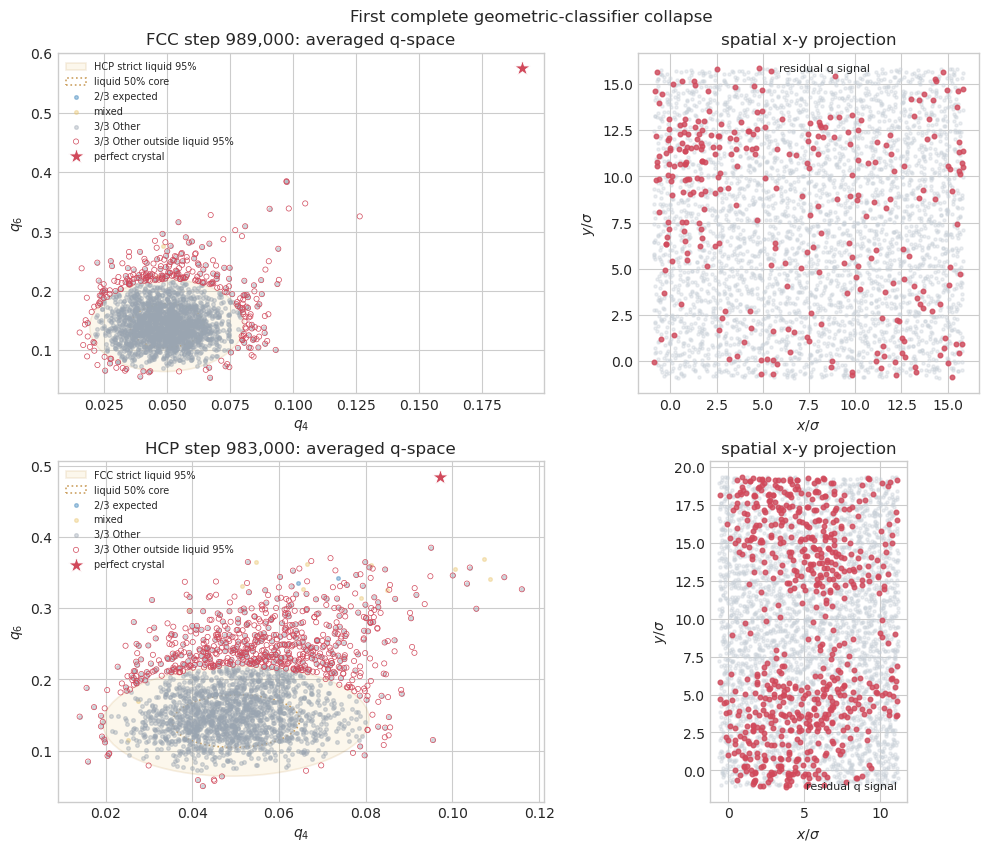

In [13]:
INSPECTION_STEPS = {}  # Example override for the pre-collapse view: {"fcc": 985000, "hcp": 977000}
averaged_q = failure_map[failure_map.feature_set.eq("averaged q")].copy()
precollapse_rows, collapse_rows = [], []
for run in RUNS:
    run_q = averaged_q[averaged_q.run.eq(run)].sort_values("timestep")
    candidates = run_q[run_q.core_unanimous_other.between(.50, COMPLETE_COLLAPSE_THRESHOLD, inclusive="left")
                       & run_q.auc_low.gt(.55)]
    if run in INSPECTION_STEPS:
        chosen_step = min(run_q.timestep, key=lambda x: abs(x - INSPECTION_STEPS[run]))
    elif not candidates.empty:
        chosen_step = int(candidates.iloc[-1].timestep)
    else:
        fallback = run_q[run_q.core_unanimous_other.lt(COMPLETE_COLLAPSE_THRESHOLD)]
        chosen_step = int(fallback.sort_values(["core_unanimous_other", "auc"]).iloc[-1].timestep)
    precollapse_rows.append(run_q[run_q.timestep.eq(chosen_step)].iloc[0])

    collapse_candidates = run_q[run_q.core_unanimous_other.ge(COMPLETE_COLLAPSE_THRESHOLD)]
    if collapse_candidates.empty:
        print(f"{run.upper()}: no frame reaches the {COMPLETE_COLLAPSE_THRESHOLD:.0%} collapse border")
        collapse_rows.append(run_q.sort_values("core_unanimous_other").iloc[-1])
    else:
        collapse_rows.append(collapse_candidates.iloc[0])

precollapse_frames = pd.DataFrame(precollapse_rows).reset_index(drop=True)
collapse_frames = pd.DataFrame(collapse_rows).reset_index(drop=True)
qcols = ["q4_lechner_dellago", "q6_lechner_dellago"]
state_colors = {"2/3 expected": "#2878b5", "mixed": "#e9c46a", "3/3 Other": "#9aa5b1"}

def plot_inspection_set(chosen_frames, figure_title, seed_offset=0):
    inspection_metrics = []
    fig, axes = plt.subplots(len(RUNS), 2, figsize=(10.5, 4.2 * len(RUNS)), constrained_layout=True)
    axes = np.atleast_2d(axes)
    for row, run in enumerate(RUNS):
        step = int(chosen_frames.loc[chosen_frames.run.eq(run), "timestep"].iloc[0])
        opposite_run = next(other for other in RUNS if other != run)
        frame = particles[particles.run.eq(run) & particles.timestep.eq(step)].copy()
        reference = empirical_liquid[empirical_liquid.run.eq(opposite_run)]
        center = reference[qcols].mean().to_numpy(); covariance = np.cov(reference[qcols].to_numpy(), rowvar=False)
        inverse = np.linalg.pinv(covariance)
        reference_delta = reference[qcols].to_numpy() - center
        reference_d2 = np.einsum("ni,ij,nj->n", reference_delta, inverse, reference_delta)
        threshold95 = np.quantile(reference_d2, .95)
        delta = frame[qcols].to_numpy() - center
        frame["outside_liquid95"] = np.einsum("ni,ij,nj->n", delta, inverse, delta) > threshold95
        frame["consensus_state"] = np.select(
            [frame.core_expected_2_of_3, frame.core_unanimous_other],
            ["2/3 expected", "3/3 Other"], default="mixed"
        )
        frame["residual_q_signal"] = frame.core_unanimous_other & frame.outside_liquid95
        state_dynamics = dynamics[dynamics.run.eq(run) & dynamics.timestep.eq(step)].iloc[0]
        inspection_metrics.append({"run": run, "timestep": step,
                                   "fraction_3_of_3_other": frame.core_unanimous_other.mean(),
                                   "fraction_residual_q_signal": frame.residual_q_signal.mean(),
                                   "unwrapped_MSD": state_dynamics.unwrapped_MSD,
                                   "passes_strict_liquid_border": bool(
                                       frame.core_unanimous_other.mean() >= LIQUID_CONSENSUS_THRESHOLD
                                       and state_dynamics.unwrapped_MSD >= LIQUID_MSD_THRESHOLD
                                       and step >= RUNS[run]["transition_step"])})

        qax, spatial_ax = axes[row]
        add_distribution_ellipse(qax, reference[qcols[0]], reference[qcols[1]], .95,
                                 facecolor="#e9c46a", edgecolor="#b7791f", alpha=.12,
                                 label=f"{opposite_run.upper()} strict liquid 95%")
        add_distribution_ellipse(qax, reference[qcols[0]], reference[qcols[1]], .50,
                                 facecolor="none", edgecolor="#b7791f", alpha=.7, linestyle=":",
                                 label="liquid 50% core")
        plot_sample = frame.sample(n=min(2000, len(frame)), random_state=40 + seed_offset + row)
        for state in state_colors:
            part = plot_sample[plot_sample.consensus_state.eq(state)]
            qax.scatter(part[qcols[0]], part[qcols[1]], s=7, alpha=.38,
                        color=state_colors[state], label=state)
        residual = frame[frame.residual_q_signal]
        qax.scatter(residual[qcols[0]], residual[qcols[1]], s=14, facecolor="none",
                    edgecolor="#d1495b", lw=.5, label="3/3 Other outside liquid 95%")
        perfect = perfect_reference.loc[run]
        qax.scatter(perfect[qcols[0]], perfect[qcols[1]], marker="*", s=140,
                    color="#d1495b", edgecolor="white", lw=.6, label="perfect crystal")
        qax.set(title=f"{run.upper()} step {step:,}: averaged q-space", xlabel=r"$q_4$", ylabel=r"$q_6$")
        qax.legend(frameon=False, fontsize=7, loc="best")

        spatial_ax.scatter(frame.x, frame.y, s=5, color="#c8d0d8", alpha=.35, rasterized=True)
        spatial_ax.scatter(residual.x, residual.y, s=11, color="#d1495b", alpha=.8,
                           label="residual q signal", rasterized=True)
        spatial_ax.set(title="spatial x-y projection", xlabel=r"$x/\sigma$", ylabel=r"$y/\sigma$", aspect="equal")
        spatial_ax.legend(frameon=False, fontsize=8)
    fig.suptitle(figure_title)
    metrics = pd.DataFrame(inspection_metrics)
    display(chosen_frames[["run", "timestep", "core_unanimous_other", "auc", "auc_low", "auc_high"]].round(3))
    display(metrics.round(3))
    plt.show()
    return metrics

print("Last distinguishable pre-collapse state")
precollapse_metrics = plot_inspection_set(
    precollapse_frames, "Pre-collapse mismatch: classifiers fail before averaged q becomes liquid-like")
print(f"First frame at or above {COMPLETE_COLLAPSE_THRESHOLD:.0%} unanimous Other")
collapse_metrics = plot_inspection_set(
    collapse_frames, "First complete geometric-classifier collapse", seed_offset=100)

## Reading the result

- `Other / liquid-like` means unclassified by a crystal template, not automatically liquid.
- The coarse overview establishes when decompression begins and how the complete simulation evolves; the consecutive event frames determine whether the apparent jump contains intermediate states.
- A falling 2-of-3 expected-crystal majority says the primary geometric rules no longer support the original lattice locally; it does not prove the true liquid fraction.
- The strict-liquid onset requires all three signals used here: at least 99% unanimous `Other`, unwrapped MSD of at least $1.0\,\sigma^2$, and a time at or after the global $Q_6$ decline.
- The first-collapse inspection deliberately tests whether 99% classifier failure and liquid-like averaged $q$ occur together. A collapse frame that fails the mobility or $q$ comparison is a disordered transitional state, not yet confirmed liquid.
- Overlap with the amber empirical-liquid distribution is the physically relevant comparison; the gray ideal gas remains a limiting reference, not a phase boundary.
- Fixed-cutoff CNA is scale-sensitive and is not part of the primary consensus. If it diverges while adaptive/interval CNA and PTM agree, inspect density or nearest-neighbor distance first.
- C2ST AUC answers whether q-space differs from an independent strict-liquid reference. It does **not** by itself answer whether residual signal uniquely identifies FCC versus HCP.

A natural next experiment is several seeds and decompression rates per starting crystal, followed by aggregation of the frame-resolved transition widths and sparse full-run summaries.